# NB03 — CLIMADA Hazard and Exposure Objects

This notebook converts the harmonised grids produced in NB02 into CLIMADA-native objects. In practice, it is the bridge between the gridded preprocessing workflow and the later mortality-impact notebooks: it turns daily `T2M` rasters into a `Hazard`, turns age-structured population rasters into `Exposures`, optionally attaches the Social Vulnerability Index (SVI), and writes the files that NB04 and the policy notebooks consume.

The key tasks in NB03 are:
- loading the shared grid metadata, city mask, hazard manifest, baseline population rasters, and optional vulnerability layer prepared in NB02;
- building one daily `T2M` hazard event per day across all target years saved in the manifest;
- correcting CLIMADA event frequencies so that each year's daily events sum to one expected year;
- constructing baseline age-differentiated exposure points on the same centroids, with age-group-specific impact-function IDs;
- saving the daily hazard, baseline exposure, and supporting event-summary tables;
- generating future scenario/year exposure objects by scaling the baseline rows with the scenario-specific grids saved in NB02.

NB03 does not define impact functions. Those are introduced in NB04. Its role is to make sure that hazard and exposure are represented in the exact format, geometry, and frequency convention that the downstream impact calculations require.


In [1]:
# Select the city run and the country identifiers reused by downstream inputs.
import os
os.environ["CITY"] = "Athens"   # city selector for this notebook copy
os.environ["WP_ISO3"] = "GRC"
os.environ["WP_COUNTRY"] = "Greece"


In [2]:
# Bootstrap the city-specific configuration and resolve the working paths.
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# `CITY` is the intended selector; the fallback below is only a notebook-local default.
SLUG = globals().get("SLUG", os.environ.get("CITY", "Lisbon")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")


→ City: athens  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim


In [3]:
cfg  = C.get("cfg")     # parsed YAML config


In [4]:
# Read the NB02 manifests and confirm that the baseline grid products exist before proceeding.
import json
from pathlib import Path

with open(INT / "exposure_manifest.json", "r") as f:
    expo_manifest = json.load(f)

BASE_POP_YEAR = 2020

age_npz = Path(expo_manifest["direct_worldpop"][str(BASE_POP_YEAR)]["age_npz"])
pop_npz = Path(expo_manifest["direct_worldpop"][str(BASE_POP_YEAR)]["pop_npz"])

needed_nb2 = [
    INT / "template_ref.tif",
    INT / "city_mask.tif",
    age_npz,
    pop_npz,
    OUT / f"{SLUG}_fua.gpkg",
    INT / "hazard_manifest.json",
    INT / "exposure_manifest.json",
]

missing = [p for p in needed_nb2 if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Re-run Notebook 2. Missing:\n" + "\n".join(map(str, missing))
    )


## Load NB02 Outputs and Core Packages

The notebook starts by loading the shared assets created in NB02: the reference grid, the city mask, the baseline population rasters, the FUA geometry, the hazard manifest, and the exposure manifest. If the vulnerability layer was produced in NB02, it is also loaded here so it can be attached to the exposure points later.


In [5]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio as rio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling
from rasterio.transform import array_bounds

from climada.hazard import Hazard, Centroids
from scipy import sparse

plt.rcParams.update({"figure.dpi": 130})

In [6]:
from pathlib import Path
import json, numpy as np, rasterio as rio
import geopandas as gpd

# Load the reference grid, city mask, baseline population rasters, FUA geometry, and hazard manifest.
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
mask_npz  = INT / "city_mask.npz"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"
manifest  = INT / "hazard_manifest.json"
exp_meta  = INT / "exposure_meta.json"

# Reference-grid metadata
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

# City mask: pixels inside the FUA with non-zero population in NB02.
if mask_tif.exists():
    with rio.open(mask_tif) as src:
        CITY_MASK = src.read(1).astype(bool)
elif mask_npz.exists():
    CITY_MASK = np.load(mask_npz)["city_mask"].astype(bool)
else:
    raise FileNotFoundError("city_mask.tif/npz not found. Re-run Notebook 2.")

assert CITY_MASK.shape == (HGT, WDT)
ref_data = np.where(CITY_MASK, 0.0, np.nan)

# Baseline age/pop rasters on the T2M reference grid.
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

# Exposure metadata
try:
    year = int(json.load(open(exp_meta))["worldpop_base_year"])
except Exception:
    year = 2020

# FUA geometry
if not fua_gp.exists():
    raise FileNotFoundError(f"{fua_gp.name} not found. Re-run Notebook 2 to save FUA.")
fua = gpd.read_file(fua_gp, layer="fua")
if fua.empty:
    raise ValueError("FUA is empty.")

# Daily T2M hazard manifest from NB02.
man_path = INT / "hazard_manifest.json"
man = json.load(open(man_path))
assert man.get("hazard_type") == "t2m_daily_mean", f"Unexpected hazard_type: {man.get('hazard_type')}"

years_all = sorted(map(int, man["files"].keys()))
years = [y for y in [2020, 2030, 2040, 2050] if y in years_all]
print("Using T2M years:", years)

t2m_paths = {int(y): Path(p) for y, p in man["files"].items()}


Using T2M years: [2020, 2030, 2040, 2050]


In [7]:
# Optional vulnerability products from NB02; attach them later to exposures if available.
from cityheat.vulnerability_layer import (
    load_vulnerability,
    add_vulnerability_to_exposure_gdf,
)


In [8]:
# Try loading the saved vulnerability layer; continue without it if it is not available.
try:
    vuln = load_vulnerability(INT, SLUG)
    svi_grid = vuln["svi"]          # 2D array on ref grid
    HAS_VULN = True
    print(f"Loaded vulnerability layer. "
          f"SVI mean={np.nanmean(svi_grid):.3f}, std={np.nanstd(svi_grid):.3f}")
    assert svi_grid.shape == (HGT, WDT), "SVI grid shape != ref grid shape"
except FileNotFoundError:
    svi_grid = None
    HAS_VULN = False
    print("No vulnerability layer found in INT – continuing without SVI.")


Loaded vulnerability layer. SVI mean=0.621, std=0.202


## CLIMADA Hazard: Daily Mean `T2M`


The hazard object is built from the daily `T2M` NetCDF files written in NB02. Each daily field becomes one CLIMADA event on the common UrbClim reference grid. The event metadata preserve the calendar date of each field so later notebooks can work at daily resolution.


In [9]:
# Build the daily T2M hazard object, with one event per day.
import xarray as xr
from scipy import sparse
from pyproj import Transformer
from climada.hazard import Hazard, Centroids

# Convert the full reference-grid centroids from EPSG:3035 to WGS84 for CLIMADA.
# Compute one centroid per reference-grid cell.
# Sanity-check that the centroid count matches the grid size.
rows, cols = np.indices((HGT, WDT))
xs_m, ys_m = rio.transform.xy(ref_meta["transform"], rows, cols, offset="center")
x_flat = np.asarray(xs_m, float).ravel()   # meters (EPSG:3035)
y_flat = np.asarray(ys_m, float).ravel()
to_wgs84 = Transformer.from_crs(ref_meta["crs"], "EPSG:4326", always_xy=True)
lon, lat = to_wgs84.transform(x_flat, y_flat)
Ctd = Centroids(lat=np.asarray(lat, float), lon=np.asarray(lon, float))

assert (getattr(ref_meta["crs"], "to_epsg", lambda: None)() == 3035), "ref grid not EPSG:3035?"
assert len(Ctd.lat) == HGT*WDT and len(Ctd.lon) == HGT*WDT, "centroids length mismatch"

# Assemble one flattened intensity row per daily T2M field.
# The daily intensity matrix has shape (n_days x n_cells).
# Loop over every saved target year and every day in each file.
# Outside the city mask, intensities are stored as zero so the sparse matrix stays well defined.
# Each 2D field is flattened into one row before all days are stacked into a sparse matrix.
I_rows, dates, years_of = [], [], []
for y in years:
    da = xr.open_dataset(t2m_paths[y])["T2M"]  # (time,y,x) in °C, already masked to FUA in NB2
    for t in da.time.values:
        arr = da.sel(time=t).values
        arr = np.where(CITY_MASK, arr, np.nan)
        I_rows.append(np.nan_to_num(arr, nan=0.0).ravel().astype("float32"))
        d = np.datetime64(t, "D")
        dates.append(d)
        years_of.append(int(str(d)[:4]))

# Each row represents one daily temperature map.
I_daily = sparse.csr_matrix(np.vstack(I_rows))  # shape = (n_days_total, HGT*WDT)

# Build the daily affected-area fraction matrix.
# `fraction` repeats the 0/1 city mask for every day.
# In CLIMADA terms, cells inside the city have fraction 1 and cells outside have fraction 0.
mask_vec = CITY_MASK.ravel().astype(float)
F_daily = sparse.csr_matrix(np.tile(mask_vec, (I_daily.shape[0], 1)))

assert I_daily.shape[1] == HGT*WDT, "events x cells shape off"
assert F_daily.shape == I_daily.shape, "fraction footprint mismatch"

# Populate the CLIMADA Hazard object.
H = Hazard("T2M")
H.haz_type   = "T2M"
H.units      = "degC (daily mean)"
H.orig       = np.array([f"{CITY}_UrbClim_T2Mmean_daily"] * I_daily.shape[0], dtype=object)
H.event_id   = np.array([int(pd.Timestamp(d).strftime("%Y%m%d")) for d in dates], dtype=int)
H.event_name = np.array([f"T2M_{str(d)}" for d in dates], dtype=object)
H.date       = np.array(dates, dtype="datetime64[ns]")
H.frequency  = np.ones(I_daily.shape[0], dtype=float)
H.centroids  = Ctd
H.intensity  = I_daily
H.fraction   = F_daily

H.check()
print(H)


### Frequency Correction

For a daily heat hazard, the relevant unit is expected annual impact, not impact per unweighted event. We therefore replace CLIMADA's default event frequency with `1 / days_in_year`, so that the event frequencies sum to one within each year and annual impacts aggregate correctly across the full daily series.


In [10]:
# Check year coverage, event counts, and calendar continuity before correcting frequencies.
years_of_arr = np.array(years_of, dtype=int)

print("Years included:", sorted(set(years_of_arr)))
print("Days per year:", {y: int((years_of_arr == y).sum()) for y in sorted(set(years_of_arr))})
print("First date:", dates[0], " | Last date:", dates[-1])

dts = np.array(dates, dtype="datetime64[D]")
diffs = np.diff(dts).astype("timedelta64[D]").astype(int)
print("Any gaps > 1 day?", np.any(diffs > 1), "| max gap:", diffs.max())

print("Hazard events:", H.size)
print("Hazard year range:", pd.to_datetime(H.date.min()).year, "-", pd.to_datetime(H.date.max()).year)


Years included: [2020, 2030, 2040, 2050]
Days per year: {2020: 366, 2030: 365, 2040: 366, 2050: 365}
First date: 2020-01-01  | Last date: 2050-12-31
Any gaps > 1 day? True | max gap: 3288
Hazard events: 1462
Hazard year range: 2020 - 2050


In [11]:
# Replace the default CLIMADA event frequency by 1 / days_in_year for each daily event.
import numpy as np
import pandas as pd

# years for each event (one row per day)
years = pd.to_datetime(H.date).year.to_numpy()

def days_in_year(y): 
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

H.frequency = np.array([1.0 / days_in_year(y) for y in years], dtype=float)
H.frequency_unit = "1/year"


In [12]:
# Save a compact event table and verify that corrected frequencies sum to one within each year.
haz_df = pd.DataFrame({
    "date": pd.to_datetime(H.date),
    "event_id": H.event_id,
    "frequency": H.frequency,
})
haz_df.to_csv(INT / f"hazard_events_T2M_daily_{SLUG}.csv", index=False)

print("Saved:", INT / f"hazard_events_T2M_daily_{SLUG}.csv")
print(haz_df.groupby(haz_df["date"].dt.year)["frequency"].sum())


# Daily summary: mean of means per year should match yearly_summary
daily = pd.read_csv(INT / f"hazard_events_T2M_daily_{SLUG}.csv", parse_dates=["date"])
print(daily.groupby(daily["date"].dt.year)["frequency"].sum())  # again 1 each year


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/hazard_events_T2M_daily_athens.csv
date
2020    1.0
2030    1.0
2040    1.0
2050    1.0
Name: frequency, dtype: float64
date
2020    1.0
2030    1.0
2040    1.0
2050    1.0
Name: frequency, dtype: float64


### Hazard Diagnostics

These plots are diagnostic checks on the assembled hazard object. They help verify spatial orientation, plausible seasonal values, and expected inter-year differences before impacts are computed from the daily fields.


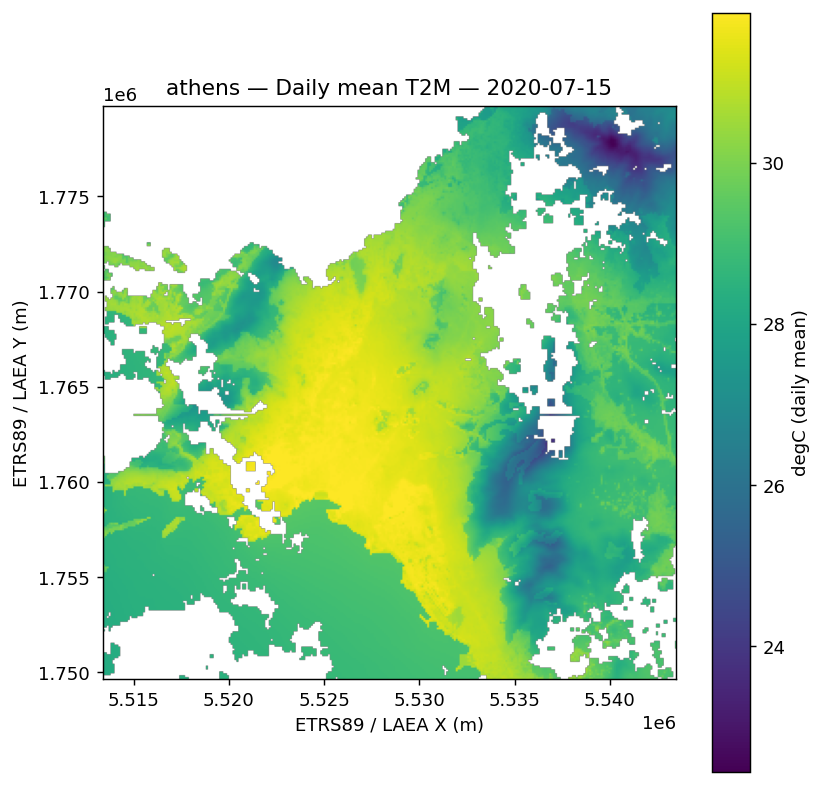

In [13]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

# Plot a single daily hazard field on the reference-grid extent (EPSG:3035).
T = ref_meta["transform"]
left, bottom, right, top = array_bounds(HGT, WDT, T)
extent = (left, right, bottom, top)

def plot_t2m_day(H, date_str):
    d = np.datetime64(date_str, 'D')
    idx = np.where(H.date.astype('datetime64[D]') == d)[0]
    if idx.size == 0:
        raise KeyError(f"No event for {date_str}")
    r = int(idx[0])

    arr = H.intensity.getrow(r).toarray().reshape(HGT, WDT)
    m = np.ma.masked_where(~CITY_MASK, arr)
    vmax = np.nanpercentile(m.compressed(), 99)

    plt.figure(figsize=(6.5, 6.2))
    im = plt.imshow(
        m,
        origin="lower",         
        extent=extent,          
        vmin=m.min(),
        vmax=vmax,
    )
    cb = plt.colorbar(im); cb.set_label("degC (daily mean)")
    plt.title(f"{CITY} — Daily mean T2M — {np.datetime_as_string(d, unit='D')}")
    plt.xlabel("ETRS89 / LAEA X (m)")
    plt.ylabel("ETRS89 / LAEA Y (m)")
    plt.gca().set_aspect('equal', 'box')
    plt.tight_layout(); plt.show()

plot_t2m_day(H, "2020-07-15")


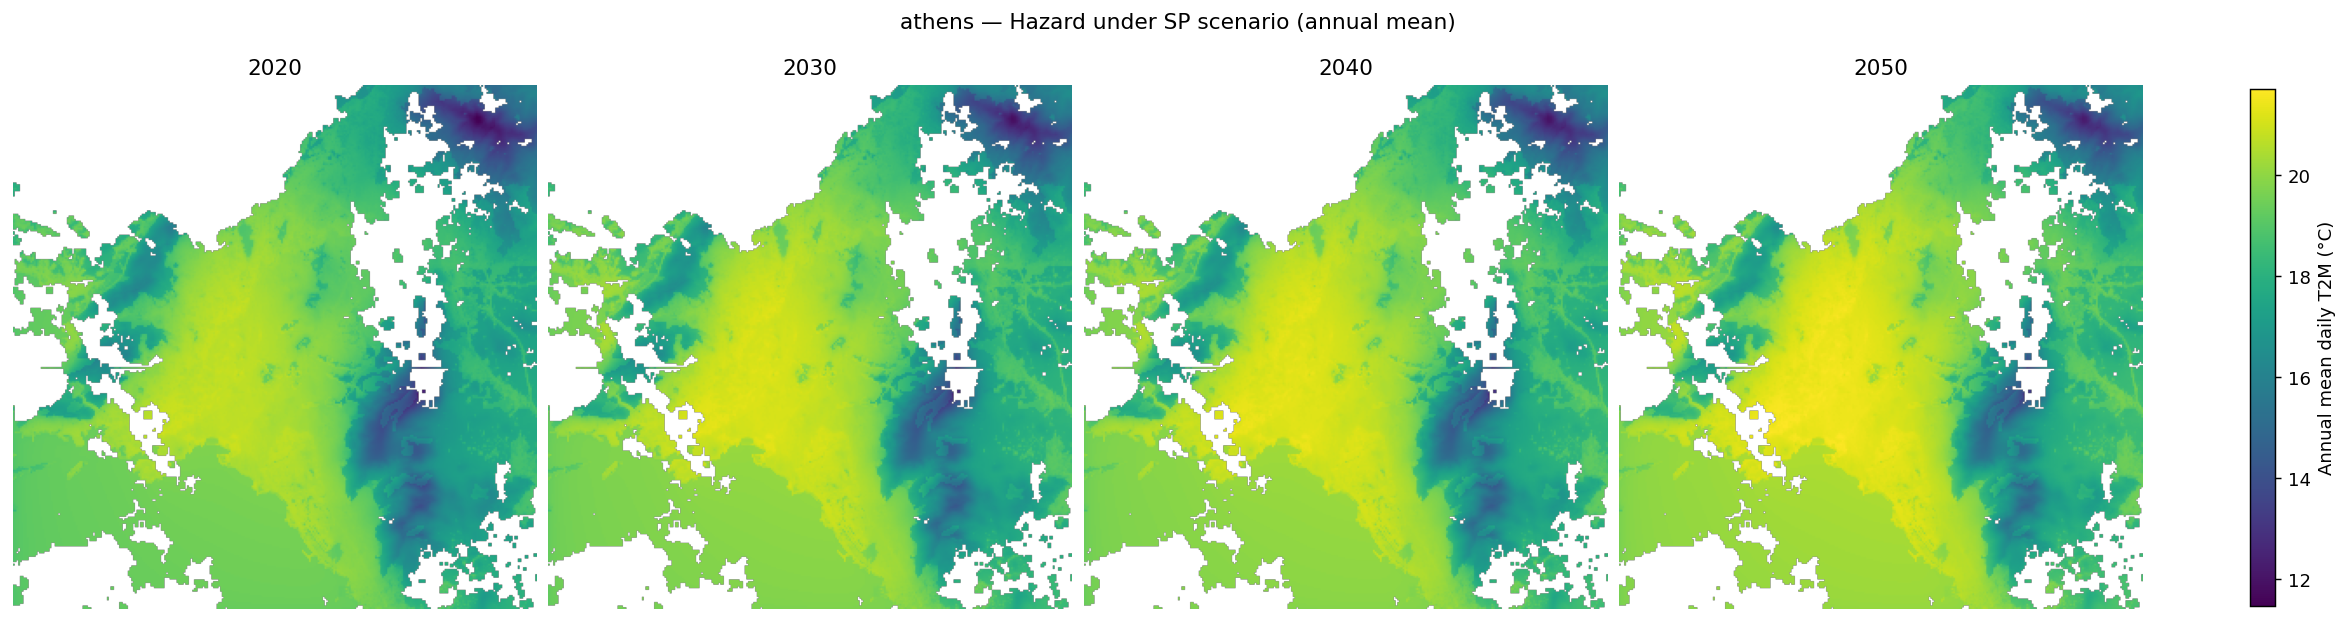

In [14]:
# Compute simple annual-mean maps from the daily hazard for a quick inter-year comparison.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def annual_mean_map(H, year):
    yrs = pd.to_datetime(H.date).year.values
    idx = np.where(yrs == year)[0]
    if idx.size == 0:
        raise ValueError(f"No events found for year={year}. Years available: {sorted(set(yrs))}")

    Iy = H.intensity[idx, :]  # (days in year) x (cells)
    mean_vec = np.array(Iy.sum(axis=0)).ravel() / len(idx)
    grid = mean_vec.reshape(HGT, WDT)
    return np.where(CITY_MASK, grid, np.nan)

years_to_plot = [2020, 2030, 2040, 2050]

maps = [annual_mean_map(H, y) for y in years_to_plot]
vmin = np.nanmin([np.nanmin(m) for m in maps])
vmax = np.nanmax([np.nanmax(m) for m in maps])

fig, axes = plt.subplots(1, len(years_to_plot), figsize=(18, 5), constrained_layout=True)

for ax, y, m in zip(axes, years_to_plot, maps):
    im = ax.imshow(m, extent=extent, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(str(y))
    ax.set_axis_off()

cbar = fig.colorbar(im, ax=axes, shrink=0.85)
cbar.set_label("Annual mean daily T2M (°C)")
fig.suptitle(f"{CITY} — Hazard under SP scenario (annual mean)")
plt.show()


## CLIMADA Exposures: Age-Differentiated Population


Exposure points are created on the same centroids as the hazard grid. Each populated grid cell contributes one row per age group, with population in the `value` column and an age-group-specific `impf_T2M` identifier pointing to the impact functions defined in NB04. If the vulnerability layer is available, its continuous SVI value is attached to each exposure point after the baseline exposure is built.


description: None
ref_year: 2020
value_unit: people
crs: EPSG:4326
data: (184266 entries)
           value age_group  impf_T2M                   geometry
0       0.004786       <15         1  POINT (23.63153 38.13498)
1       0.012908       <15         1  POINT (23.63265 38.13481)
2       0.038943       <15         1  POINT (23.63377 38.13465)
3       0.026237       <15         1  POINT (23.63489 38.13449)
184262  0.671461       65+         3  POINT (23.86417 37.82592)
184263  0.466219       65+         3  POINT (23.86529 37.82575)
184264  0.275805       65+         3   POINT (23.8664 37.82559)
184265  0.324771       65+         3  POINT (23.86752 37.82543)
Total people in exposure (T2M grid): 3424647.818966732
Breakdown by age group (T2M grid):
age_group
15-64    2.270311e+06
65+      6.931959e+05
<15      4.611410e+05
Name: value, dtype: float64


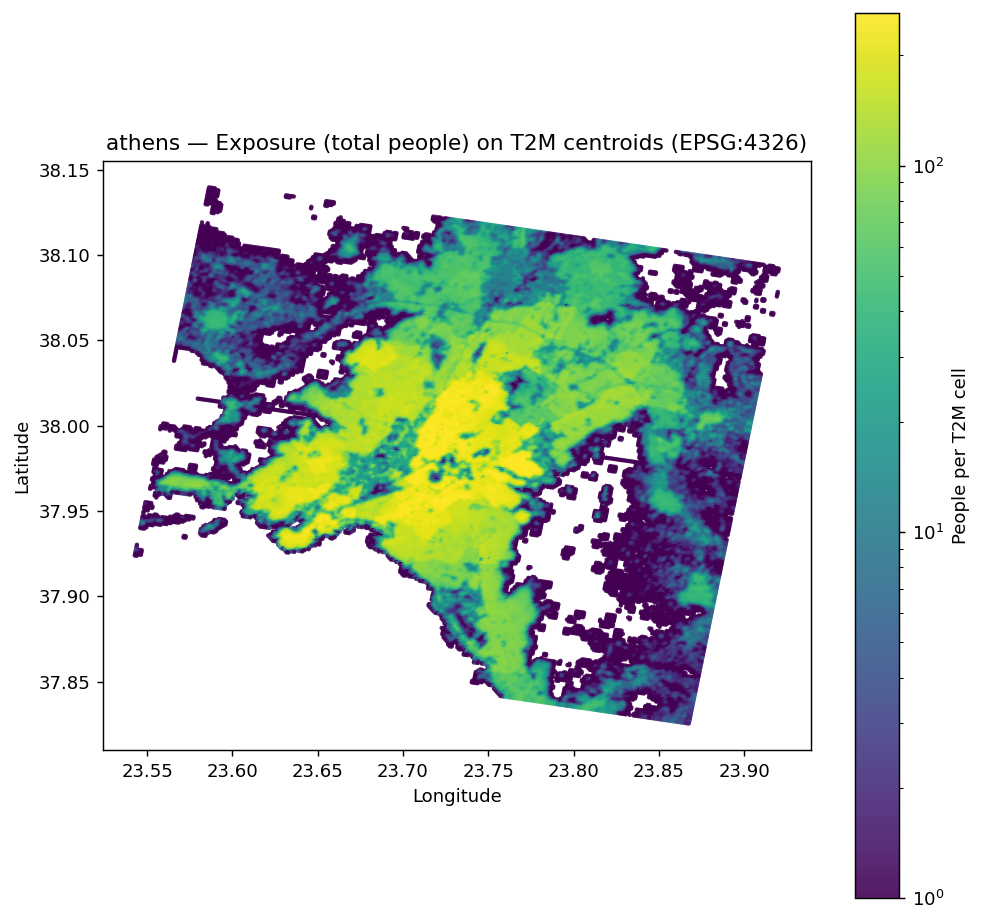

Exposure total (check): 3,424,648 people


In [15]:
# Build the baseline exposure on the same centroids as the hazard grid.

# Only create exposure rows for valid city pixels.
haz_valid = CITY_MASK.ravel() # only create exposure points for cells inside FUA, and also only where population is > 0

# Age-group-specific impact-function IDs used later in NB04.
impf_id_T2M = {"<15": 1, "15-64": 2, "65+": 3}

# Create one exposure row per populated cell and age group.
frames = []
for grp, raster in age_on_ref.items():
    pop_flat = np.nan_to_num(raster, nan=0.0).ravel().astype(float)
    valid = haz_valid & (pop_flat > 0)
    if valid.any():
        frames.append(
            gpd.GeoDataFrame(
                {
                    "value":     pop_flat[valid],
                    "longitude": lon[valid],    # longitude of the reference-grid centroid
                    "latitude":  lat[valid],    # latitude of the reference-grid centroid
                    "age_group": np.full(valid.sum(), grp, dtype=object),
                    "impf_T2M":  np.full(valid.sum(), impf_id_T2M[grp], dtype=int),
                },
                geometry=gpd.points_from_xy(lon[valid], lat[valid]),
                crs="EPSG:4326",
            )
        )

gdf = pd.concat(frames, ignore_index=True) if frames else gpd.GeoDataFrame(
    columns=["value","longitude","latitude","age_group","impf_T2M","geometry"], crs="EPSG:4326"
)

# Instantiate the CLIMADA Exposures object.
from climada.entity.exposures import Exposures
exp = Exposures()
exp.set_gdf(gdf)
exp.value_unit = "people"
exp.ref_year   = year
exp.tag        = f"{CITY} FUA — WorldPop age groups ({year}) on T2M (UrbClim) grid"
exp.check()

print(exp)
if not exp.gdf.empty:
    print("Total people in exposure (T2M grid):", float(exp.gdf["value"].sum()))
    print("Breakdown by age group (T2M grid):")
    print(exp.gdf.groupby("age_group")["value"].sum().astype(float))

# Quick map of total population on the T2M centroids.
from matplotlib.colors import LogNorm
vals_all  = np.nan_to_num(pop_on_ref, nan=0.0)
valid_all = CITY_MASK
vmax = np.nanpercentile(vals_all[valid_all], 99) if valid_all.any() else 1.0
norm = LogNorm(vmin=1, vmax=max(1.0, vmax))

plt.figure(figsize=(7.8, 7.2))
sc = plt.scatter(lon[valid_all.ravel()], lat[valid_all.ravel()],
                 c=vals_all.ravel()[valid_all.ravel()], s=6, linewidths=0, alpha=0.9, norm=norm)
cb = plt.colorbar(sc); cb.set_label("People per T2M cell")
plt.title(f"{CITY} — Exposure (total people) on T2M centroids (EPSG:4326)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.gca().set_aspect('equal', 'box')
plt.tight_layout(); plt.show()

print(f"Exposure total (check): {vals_all[valid_all].sum():,.0f} people")


In [16]:
# Sanity checks on grid shapes and centroid counts.
assert CITY_MASK.shape == (HGT, WDT)
assert lon.shape[0] == HGT * WDT and lat.shape[0] == HGT * WDT
for grp, raster in age_on_ref.items():
    assert raster.shape == (HGT, WDT)


In [17]:
# Attach the continuous SVI value to each exposure point when the vulnerability layer is available.
if HAS_VULN:
    add_vulnerability_to_exposure_gdf(exp.gdf, svi_grid, ref_meta)

    # Fill remaining invalid values conservatively so downstream CLIMADA code does not fail.
    exp.gdf["vulnerability"] = exp.gdf["vulnerability"].replace([np.inf, -np.inf], np.nan)
    exp.gdf["vulnerability"] = exp.gdf["vulnerability"].fillna(exp.gdf["vulnerability"].median())

    print(exp.gdf["vulnerability"].describe())


count    184266.000000
mean          0.621620
std           0.196422
min           0.000000
25%           0.498269
50%           0.632844
75%           0.750703
max           1.000000
Name: vulnerability, dtype: float64


## Saving Hazard and Baseline Exposure

The next block writes the baseline CLIMADA objects and a few supporting summaries. In addition to the HDF5 hazard and exposure files, the notebook exports date/event lookup tables and simple daily or annual summaries that are useful for checking what was actually encoded in the CLIMADA hazard.


In [18]:
# Close any previously open HDF5 handles before writing CLIMADA objects.
import tables
tables.file._open_files.close_all()

# Save the baseline daily hazard and exposure objects.
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"

H.write_hdf5(haz_path)
exp.write_hdf5(exp_path)
print("Saved daily hazard →", haz_path, "| days:", H.intensity.shape[0])

# Save a row-to-date lookup because HDF5 does not preserve all event labels directly.
dates_df = pd.DataFrame({
    "row": np.arange(H.intensity.shape[0], dtype=int),
    "event_id": np.asarray(H.event_id, dtype=int),
    "date": pd.to_datetime(H.date).astype(str),
})
dates_csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
dates_df.to_csv(dates_csv, index=False)
print("Saved events map →", dates_csv)

# Save a simple per-day summary derived from the hazard object.
mean_by_event = np.asarray(H.intensity.mean(axis=1)).ravel()  # citywide mean °C per day
daily_summary = pd.DataFrame({
    "row": np.arange(H.intensity.shape[0], dtype=int),
    "event_id": np.asarray(H.event_id, dtype=int),
    "date": pd.to_datetime(H.date),
    "frequency": np.asarray(H.frequency, dtype=float),
    "mean_intensity_degC": mean_by_event,
})
daily_csv = INT / f"hazard_events_T2M_daily_{SLUG}.csv"
daily_summary.to_csv(daily_csv, index=False)
print("Saved daily summary →", daily_csv)

# Also save a yearly summary aggregated from the daily hazard.
yearly_summary = (
    daily_summary
    .assign(year=lambda d: d["date"].dt.year.astype(int))
    .groupby("year", as_index=False)
    .agg(
        n_days=("row", "count"),
        citymean_degC=("mean_intensity_degC", "mean")
    )
)
yearly_csv = INT / f"hazard_events_T2M_yearly_{SLUG}.csv"
yearly_summary.to_csv(yearly_csv, index=False)
print("Saved yearly summary →", yearly_csv)


2026-03-26 17:24:02,265 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Saved daily hazard → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/hazard_T2M_daily_athens.h5 | days: 1462
Saved events map → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/hazard_T2M_daily_events_athens.csv
Saved daily summary → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/hazard_events_T2M_daily_athens.csv
Saved yearly summary → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/hazard_events_T2M_yearly_athens.csv


In [19]:
# Save the same baseline CLIMADA objects again and copy them to OUT for easier downstream access.
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"
H.write_hdf5(haz_path)
exp.write_hdf5(exp_path)
print("Saved daily hazard →", haz_path, "| days:", H.intensity.shape[0])

# Also copy the files to OUT so later notebooks can find them easily.
import shutil
haz_path_out = OUT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path_out = OUT / f"exposure_people_{SLUG}.h5"
haz_path_out.parent.mkdir(parents=True, exist_ok=True)
exp_path_out.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(haz_path, haz_path_out)
shutil.copy2(exp_path, exp_path_out)
print("Copied to OUT →", haz_path_out)
print("Copied to OUT →", exp_path_out)


2026-03-26 17:24:06,107 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Saved daily hazard → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/hazard_T2M_daily_athens.h5 | days: 1462
Copied to OUT → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/hazard_T2M_daily_athens.h5
Copied to OUT → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/exposure_people_athens.h5


In [20]:
# Build a compact yearly T2M grid summary from the daily hazard.
import numpy as np
import pandas as pd
import rasterio as rio

# Load the grid shape from the reference template.
tmpl_path = INT / "template_ref.tif"
with rio.open(tmpl_path) as src:
    HGT, WDT = src.height, src.width

n_days, n_cells = H.intensity.shape
assert n_cells == HGT * WDT, f"Cells {n_cells} != HGT*WDT = {HGT*WDT}"

# Year per event
dates = pd.to_datetime(pd.Series(H.date))
years = dates.dt.year.to_numpy().astype(int)
uniq_years = np.unique(years)

# For each year, compute mean daily T2M per cell and reshape back to 2D.
DATA = np.empty((len(uniq_years), HGT, WDT), dtype="float32")
for k, yr in enumerate(uniq_years):
    mask = (years == yr)
    # Mean over all days in that year => one value per cell
    arr_1d = np.asarray(H.intensity[mask].mean(axis=0), dtype="float32")
    DATA[k, :, :] = arr_1d.reshape(HGT, WDT)

# Save the result as a compact NumPy archive.
t2m_npz_path = INT / f"t2m_hazard_2020_2050_{SLUG}.npz"
np.savez_compressed(t2m_npz_path, years=uniq_years, data=DATA)
print("Saved yearly T2M hazard grid →", t2m_npz_path)


Saved yearly T2M hazard grid → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/t2m_hazard_2020_2050_athens.npz


In [21]:
# Save the baseline exposure carrying the attached vulnerability values for later scaling.

from climada.entity.exposures import Exposures
import shutil

base_exp_path = INT / f"exposure_with_vulnerability_{SLUG}.h5"
exp.write_hdf5(base_exp_path)
print("Saved baseline exposure-with-vulnerability →", base_exp_path)

# Also copy the file to OUT for easier downstream reuse.
base_exp_out = OUT / base_exp_path.name
shutil.copy2(base_exp_path, base_exp_out)
print("Copied to OUT →", base_exp_out)


Saved baseline exposure-with-vulnerability → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/exposure_with_vulnerability_athens.h5
Copied to OUT → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/exposure_with_vulnerability_athens.h5


## Future Exposure Objects

Future CLIMADA exposures are generated from the scenario/year grids saved in NB02. The scaling is done age group by age group and cell by cell, so the baseline row structure is preserved while the `value` field is updated to match the future population totals. The vulnerability column, when present, is kept static because NB03 does not model future changes in social vulnerability.


In [22]:
import json
import numpy as np
from climada.entity import Exposures

# Load the baseline exposure object, optionally carrying a continuous vulnerability column.
base_exp_path = INT / f"exposure_with_vulnerability_{SLUG}.h5"
print("Reading baseline exposure from:", base_exp_path)
exp_base = Exposures.from_hdf5(base_exp_path)

# Clean the vulnerability column so scaling does not propagate invalid values.
if "vulnerability" in exp_base.gdf.columns:
    exp_base.gdf["vulnerability"] = exp_base.gdf["vulnerability"].replace([np.inf, -np.inf], np.nan)
    exp_base.gdf["vulnerability"] = exp_base.gdf["vulnerability"].fillna(exp_base.gdf["vulnerability"].median())
    print(exp_base.gdf["vulnerability"].describe())

# Reuse the baseline arrays loaded earlier in the notebook.
pop_base = pop_on_ref.astype("float32")
age_on_ref = {k: v.astype("float32") for k, v in age_on_ref.items()}

CITY_MASK = np.load(INT / "city_mask.npz")["city_mask"].astype(bool)
HGT, WDT = CITY_MASK.shape
haz_valid = CITY_MASK.ravel()

# Sanity checks on baseline grid shapes.
assert pop_base.shape == (HGT, WDT)
for grp, arr in age_on_ref.items():
    assert arr.shape == (HGT, WDT), f"Age raster shape mismatch for {grp}"

# Build a mapping from age-group exposure rows back to the corresponding grid cells.
idx_by_group = {}

for grp, raster in age_on_ref.items():
    pop_flat_age = np.nan_to_num(raster, nan=0.0).ravel().astype(float)
    valid_age = haz_valid & (pop_flat_age > 0)

    cell_idx = np.where(valid_age)[0]
    rows_idx = np.where(exp_base.gdf["age_group"].values == grp)[0]

    print(f"Group {grp}: {valid_age.sum()} cells, {len(rows_idx)} exposure rows")
    assert len(cell_idx) == len(rows_idx), f"Mismatch for group {grp}"

    idx_by_group[grp] = (rows_idx, cell_idx)

print("Total exposure rows:", len(exp_base.gdf))

# Load the manifest and scale exposures for each scenario/year listed there.
with open(INT / "exposure_manifest.json") as f:
    expo_manifest = json.load(f)

for scen_code, years_dict in expo_manifest["scenarios"].items():
    for year_str, rec in years_dict.items():
        year = int(year_str)

        # Load the future age-group grids prepared in NB02.
        ages_future_npz = np.load(rec["age_npz"])
        age_future = {
            "<15":   ages_future_npz["lt15"].astype("float32"),
            "15-64": ages_future_npz["a15_64"].astype("float32"),
            "65+":   ages_future_npz["g65"].astype("float32"),
        }

        for grp in ["<15", "15-64", "65+"]:
            assert age_future[grp].shape == age_on_ref[grp].shape

        # Start from the baseline exposure, which already carries the static vulnerability column.
        exp_y = exp_base.copy()

        # Scale each age group cell by cell.
        for grp in ["<15", "15-64", "65+"]:
            rows_idx, cell_idx = idx_by_group[grp]

            base_grid = age_on_ref[grp]
            fut_grid  = age_future[grp]

            scale_grid = np.ones_like(base_grid, dtype="float32")
            nz = base_grid > 0
            scale_grid[nz] = fut_grid[nz] / base_grid[nz]

            scale_flat = scale_grid.ravel()
            scale_for_rows = scale_flat[cell_idx]

            base_vals = exp_base.gdf.loc[rows_idx, "value"].to_numpy(dtype=float)
            exp_y.gdf.loc[rows_idx, "value"] = base_vals * scale_for_rows

        # Consistency check against the future total-population grid.
        pop_future = np.load(rec["pop_npz"])["pop"].astype("float32")
        tot_exp  = float(exp_y.gdf["value"].sum())
        tot_grid = float(pop_future[CITY_MASK].sum())
        print(f"{scen_code} {year}: exposure={tot_exp:,.0f}  grid_pop={tot_grid:,.0f}")

        out_path = OUTP(f"exposure_with_vulnerability_{SLUG}_{scen_code}_{year}.h5")
        exp_y.write_hdf5(out_path)
        print("Saved", out_path)


Reading baseline exposure from: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/exposure_with_vulnerability_athens.h5
count    184266.000000
mean          0.621620
std           0.196422
min           0.000000
25%           0.498269
50%           0.632844
75%           0.750703
max           1.000000
Name: vulnerability, dtype: float64
Group <15: 61422 cells, 61422 exposure rows
Group 15-64: 61422 cells, 61422 exposure rows
Group 65+: 61422 cells, 61422 exposure rows
Total exposure rows: 184266
SSP1 2040: exposure=3,174,783  grid_pop=3,174,783
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/exposure_with_vulnerability_athens_SSP1_2040.h5
SSP1 2050: exposure=3,110,732  grid_pop=3,110,732
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/exposure_with_vulnerability_athens_SSP1_2050.h5
SSP2 2040: exposure=3,166,253  grid_pop=3,166,254
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAP